In [12]:
import mne
from pathlib import Path
from mne import pick_types

tmin=0
tmax=4

all_epochs = {}
all_epochs["regr"] = []

for subject in range(1, 10):
    raw = mne.io.read_raw_fif(Path("preproc", f"A0{subject}_regr_raw.fif"), preload=True)
    filt_raw = raw.filter(l_freq=8, h_freq=30)

    # Epoch
    events, event_id = mne.events_from_annotations(filt_raw)
    picks = pick_types(filt_raw.info, meg=False, eeg=True, stim=False, eog=False, exclude="bads")
    epochs = mne.Epochs(filt_raw, events, event_id=event_id, picks=picks, tmin=tmin, tmax=tmax, baseline=None, preload=True, event_repeated='drop')

    all_epochs["regr"].append(epochs)

Opening raw data file preproc/A01_regr_raw.fif...
Isotrak not found
    Range : 0 ... 672527 =      0.000 ...  2690.108 secs
Ready.
Reading 0 ... 672527  =      0.000 ...  2690.108 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)

Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
Multiple event values for single event times found. Kee

In [17]:
from augmentation import *

augment_fns = [
    lambda x, y: add_gaussian_noise(x, y, sigma=0.05),
    lambda x, y: time_shift(x, y, max_shift=25),
    lambda x, y: channel_dropout(x, y, p=0.1),
    lambda x, y: same_class_mixup(x, y, alpha=0.2),
    lambda x, y: freq_perturb(x, y, scale=0.1)
]

import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import cohen_kappa_score, accuracy_score
from sklearn.preprocessing import LabelEncoder
from torch import nn
import pickle
import os
from datetime import datetime

from EEGNet import EEGNet, train

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for subject in range(9):
    epochs = all_epochs["regr"][subject]

    # Pick only the epochs leading up to the 4 class labels
    target_epochs = epochs[['769', '770', '771', '772']]

    X = target_epochs.get_data()
    X = X[:, np.newaxis, :, :] 

    y_raw = target_epochs.events[:, -1]
    y = LabelEncoder().fit_transform(y_raw)

    # Normalize per-trial or per-channel — z-score is standard
    X = (X - X.mean(axis=(2,3), keepdims=True)) / X.std(axis=(2,3), keepdims=True)

    X = torch.tensor(X, dtype=torch.float32).to(device)
    y = torch.tensor(y, dtype=torch.long).to(device)

    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

    train_ds = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

    val_ds = TensorDataset(X_val, y_val)
    val_loader = DataLoader(val_ds, batch_size=32, shuffle=True)

    model = EEGNet(n_classes=4, n_channels=X_train.shape[2], n_samples=X_train.shape[3])
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    n_epochs = 50
    patience = 5

    for i in range(len(augment_fns)):
        best_model, history = train(model, train_loader, val_loader, optimizer, criterion, n_epochs, patience, device, metrics=[accuracy_score, cohen_kappa_score], augmentation_fns=[augment_fns[i]])

        # Save the model
        save_path = 'models_aug'

        # Create the directory if it doesn't exist
        os.makedirs(save_path, exist_ok=True)

        # Get current timestamp
        # timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

        # Save the best_model's state dictionary
        model_save_path = os.path.join(save_path, f'aug{i+1}_subject_{subject+1}_best_eegnet_model.pth')
        torch.save(best_model.state_dict(), model_save_path)
        print(f"Best model saved to: {model_save_path}")

        # Save the training history
        history_save_path = os.path.join(save_path, f'aug{i+1}_subject_{subject+1}_eegnet_history.pkl')
        with open(history_save_path, 'wb') as f:
            pickle.dump(history, f)
        print(f"History saved to: {history_save_path}")

1 	 1.3906 	 1.3855 	 0.3087 	 0.2414
best val loss inf -> 1.3855
2 	 1.3919 	 1.3879 	 0.2696 	 0.2069
3 	 1.3598 	 1.3848 	 0.3043 	 0.2414
best val loss 1.3855 -> 1.3848
4 	 1.3510 	 1.3804 	 0.3304 	 0.2069
best val loss 1.3848 -> 1.3804
5 	 1.3191 	 1.3755 	 0.3739 	 0.2069
best val loss 1.3804 -> 1.3755
6 	 1.3143 	 1.3645 	 0.3435 	 0.2241
best val loss 1.3755 -> 1.3645
7 	 1.3097 	 1.3521 	 0.4000 	 0.2759
best val loss 1.3645 -> 1.3521
8 	 1.2733 	 1.3394 	 0.4304 	 0.3103
best val loss 1.3521 -> 1.3394
9 	 1.2450 	 1.3206 	 0.4565 	 0.3966
best val loss 1.3394 -> 1.3206
10 	 1.2185 	 1.2774 	 0.5174 	 0.4828
best val loss 1.3206 -> 1.2774
11 	 1.2057 	 1.2199 	 0.5000 	 0.5345
best val loss 1.2774 -> 1.2199
12 	 1.1270 	 1.1773 	 0.5391 	 0.4828
best val loss 1.2199 -> 1.1773
13 	 1.1350 	 1.1149 	 0.5391 	 0.5690
best val loss 1.1773 -> 1.1149
14 	 1.0589 	 1.0483 	 0.5043 	 0.6207
best val loss 1.1149 -> 1.0483
15 	 1.0291 	 0.9799 	 0.5565 	 0.6552
best val loss 1.0483 -> 

In [21]:
all_inses_accs_aug = []
all_inses_kappas_aug = []

for aug_idx in range(len(augment_fns)):
    inses_accs_dict = {}
    inses_kappas_dict = {}

    for subject in range(1, 10):
        with open(Path('models_aug', f'aug{aug_idx+1}_subject_{subject}_eegnet_history.pkl'), 'rb') as f:
            history = pickle.load(f)
        best_loss = np.inf
        best_acc = 0
        best_kappa = 0
        for dict in history:
            if dict['valid_loss'] < best_loss:
                best_loss = dict['valid_loss']
                best_acc = dict['valid_perf'][0]
                best_kappa = dict['valid_perf'][1]
        inses_accs_dict[subject] = best_acc
        inses_kappas_dict[subject] = best_kappa

    inses_accs_aug = []
    inses_kappas_aug = []
    for i in range(1, 10):
        inses_accs_aug.append(inses_accs_dict[i])
        inses_kappas_aug.append(inses_kappas_dict[i])

    all_inses_accs_aug.append(inses_accs_aug)
    all_inses_kappas_aug.append(inses_kappas_aug)

In [22]:
from mne.preprocessing import EOGRegression
from scipy.io import loadmat

datadir = "BCICIV_2a_gdf"

save_path = "models_aug"

all_outses_accs_aug = []
all_outses_kappas_aug = []

for aug_idx in range(len(augment_fns)):

    outses_accs_aug = []
    outses_kappas_aug = []

    for subject in range(1, 10):
        model_save_path = os.path.join(save_path, f'aug{aug_idx+1}_subject_{subject}_best_eegnet_model.pth')
        model = EEGNet(n_classes=4, n_channels=22, n_samples=1001)
        model.load_state_dict(torch.load(f=model_save_path))

        # Load test session
        raw = mne.io.read_raw_gdf(Path(datadir, f"A0{subject}E.gdf"), preload=True)

        # Test session preprocessing
        # Mark the EOG channels
        raw.set_channel_types({'EOG-left': 'eog', 'EOG-central': 'eog', 'EOG-right': 'eog'})

        # Reference using CAR
        ref_raw = mne.set_eeg_reference(raw, 'average', projection=False)[0]

        # Remove slow drifts from the signal
        filt_raw = ref_raw.filter(l_freq=1, h_freq=None)

        # EOG Regression
        weights = EOGRegression(picks="eeg", picks_artifact="eog").fit(filt_raw)
        regr_raw = weights.apply(filt_raw, copy=True)

        # Bandpass filter to mu/beta band
        mubeta_raw = regr_raw.filter(l_freq=8, h_freq=30)

        # Epoch
        events, event_id = mne.events_from_annotations(mubeta_raw)
        picks = pick_types(mubeta_raw.info, meg=False, eeg=True, stim=False, eog=False, exclude="bads")
        epochs = mne.Epochs(mubeta_raw, events, event_id=event_id, picks=picks, tmin=tmin+2, tmax=tmax+2, baseline=None, preload=True, event_repeated='drop')
        trial_epochs = epochs[['768']]

        # Get data and labels
        X = trial_epochs.get_data()
        X = X[:, np.newaxis, :, :]
        X = (X - X.mean(axis=(2,3), keepdims=True)) / X.std(axis=(2,3), keepdims=True)
        X = torch.tensor(X, dtype=torch.float32).to(device)

        # Get true labels
        y_true = LabelEncoder().fit_transform(loadmat(Path(datadir, 'true_labels', f'A0{subject}E.mat'))['classlabel'].flatten())
        
        y_pred = torch.argmax(model(X), axis=1)

        outses_accs_aug.append(accuracy_score(y_true, y_pred))
        outses_kappas_aug.append(cohen_kappa_score(y_true, y_pred))

    all_outses_accs_aug.append(outses_accs_aug)
    all_outses_kappas_aug.append(outses_kappas_aug)

np.savetxt(Path('results', 'eegnet_all_inses_accs_aug.csv'), all_inses_accs_aug, delimiter=',')
np.savetxt(Path('results', 'eegnet_all_inses_kappas_aug.csv'), all_inses_kappas_aug, delimiter=',')
np.savetxt(Path('results', 'eegnet_all_outses_accs_aug.csv'), all_outses_accs_aug, delimiter=',')
np.savetxt(Path('results', 'eegnet_all_outses_kappas_aug.csv'), all_outses_kappas_aug, delimiter=',')

Extracting GDF parameters from BCICIV_2a_gdf/A01E.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 686999  =      0.000 ...  2747.996 secs...


/home/david-daubner/Apps/miniconda3/envs/eeg-torch/lib/python3.14/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 825 samples (3.300 s)

No projector specified for this dataset. Please consider the method self.add_proj.
No projector specified for this dataset. Please consider the method self.add_proj.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passban

/home/david-daubner/Apps/miniconda3/envs/eeg-torch/lib/python3.14/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 825 samples (3.300 s)

No projector specified for this dataset. Please consider the method self.add_proj.
No projector specified for this dataset. Please consider the method self.add_proj.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passban

...

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 825 samples (3.300 s)

No projector specified for this dataset. Please consider the method self.add_proj.
No projector specified for this dataset. Please consider the method self.add_proj.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passban

/home/david-daubner/Apps/miniconda3/envs/eeg-torch/lib/python3.14/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 825 samples (3.300 s)

No projector specified for this dataset. Please consider the method self.add_proj.
No projector specified for this dataset. Please consider the method self.add_proj.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passban

/home/david-daubner/Apps/miniconda3/envs/eeg-torch/lib/python3.14/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 825 samples (3.300 s)

No projector specified for this dataset. Please consider the method self.add_proj.
No projector specified for this dataset. Please consider the method self.add_proj.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passban

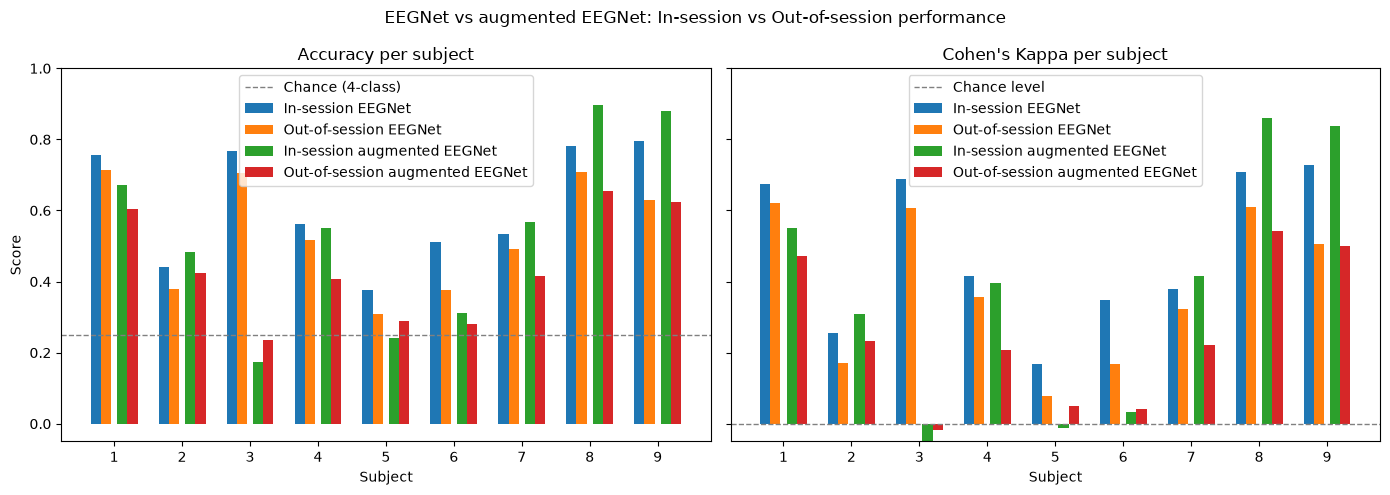

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

inses_accs = np.loadtxt(Path('results', 'eegnet_inses_accs_regr.csv'), delimiter=',')
outses_accs = np.loadtxt(Path('results', 'eegnet_outses_accs.csv'), delimiter=',')
inses_kappas = np.loadtxt(Path('results', 'eegnet_inses_kappas_regr.csv'), delimiter=',')
outses_kappas = np.loadtxt(Path('results', 'eegnet_outses_kappas.csv'), delimiter=',')

inses_accs_aug = np.loadtxt(Path('results', 'eegnet_inses_accs_aug.csv'), delimiter=',')
outses_accs_aug = np.loadtxt(Path('results', 'eegnet_outses_accs_aug.csv'), delimiter=',')
inses_kappas_aug = np.loadtxt(Path('results', 'eegnet_inses_kappas_aug.csv'), delimiter=',')
outses_kappas_aug = np.loadtxt(Path('results', 'eegnet_outses_kappas_aug.csv'), delimiter=',')

n = len(inses_accs)
x = np.arange(n)
width = 0.15  # narrower to fit 4 bars per subject

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# --- Accuracy subplot ---
ax = axes[0]
ax.bar(x - 1.8*width, inses_accs, width, label="In-session EEGNet")
ax.bar(x - 0.8*width, outses_accs, width, label="Out-of-session EEGNet")
ax.bar(x + 0.8*width, inses_accs_aug, width, label="In-session augmented EEGNet")
ax.bar(x + 1.8*width, outses_accs_aug, width, label="Out-of-session augmented EEGNet")
ax.set_title("Accuracy per subject")
ax.set_xlabel("Subject")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(list(range(1, 10)))
ax.axhline(0.25, color="gray", linestyle="--", linewidth=1, label="Chance (4-class)")
ax.legend()
ax.set_ylim(0, 1)

# --- Kappa subplot ---
ax = axes[1]
ax.bar(x - 1.8*width, inses_kappas, width, label="In-session EEGNet")
ax.bar(x - 0.8*width, outses_kappas, width, label="Out-of-session EEGNet")
ax.bar(x + 0.8*width, inses_kappas_aug, width, label="In-session augmented EEGNet")
ax.bar(x + 1.8*width, outses_kappas_aug, width, label="Out-of-session augmented EEGNet")
ax.set_title("Cohen's Kappa per subject")
ax.set_xlabel("Subject")
ax.set_xticks(x)
ax.set_xticklabels(list(range(1, 10)))
ax.axhline(0.0, color="gray", linestyle="--", linewidth=1, label="Chance level")
ax.legend()
ax.set_ylim(-0.05, 1)

fig.suptitle("EEGNet vs augmented EEGNet: In-session vs Out-of-session performance")
fig.tight_layout()
# fig.savefig("subject_scores.png", dpi=150)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

inses_accs = np.loadtxt(Path('results', 'eegnet_inses_accs_regr.csv'), delimiter=',')
outses_accs = np.loadtxt(Path('results', 'eegnet_outses_accs.csv'), delimiter=',')
inses_kappas = np.loadtxt(Path('results', 'eegnet_inses_kappas_regr.csv'), delimiter=',')
outses_kappas = np.loadtxt(Path('results', 'eegnet_outses_kappas.csv'), delimiter=',')

inses_accs_aug = np.loadtxt(Path('results', 'eegnet_inses_accs_aug.csv'), delimiter=',')
outses_accs_aug = np.loadtxt(Path('results', 'eegnet_outses_accs_aug.csv'), delimiter=',')
inses_kappas_aug = np.loadtxt(Path('results', 'eegnet_inses_kappas_aug.csv'), delimiter=',')
outses_kappas_aug = np.loadtxt(Path('results', 'eegnet_outses_kappas_aug.csv'), delimiter=',')

n = len(inses_accs)
x = np.arange(n)
width = 0.15  # narrower to fit 4 bars per subject

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# --- Accuracy subplot ---
ax = axes[0]
ax.bar(x - 1.8*width, inses_accs, width, label="In-session EEGNet")
ax.bar(x - 0.8*width, outses_accs, width, label="Out-of-session EEGNet")
ax.bar(x + 0.8*width, inses_accs_aug, width, label="In-session augmented EEGNet")
ax.bar(x + 1.8*width, outses_accs_aug, width, label="Out-of-session augmented EEGNet")
ax.set_title("Accuracy per subject")
ax.set_xlabel("Subject")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(list(range(1, 10)))
ax.axhline(0.25, color="gray", linestyle="--", linewidth=1, label="Chance (4-class)")
ax.legend()
ax.set_ylim(0, 1)

# --- Kappa subplot ---
ax = axes[1]
ax.bar(x - 1.8*width, inses_kappas, width, label="In-session EEGNet")
ax.bar(x - 0.8*width, outses_kappas, width, label="Out-of-session EEGNet")
ax.bar(x + 0.8*width, inses_kappas_aug, width, label="In-session augmented EEGNet")
ax.bar(x + 1.8*width, outses_kappas_aug, width, label="Out-of-session augmented EEGNet")
ax.set_title("Cohen's Kappa per subject")
ax.set_xlabel("Subject")
ax.set_xticks(x)
ax.set_xticklabels(list(range(1, 10)))
ax.axhline(0.0, color="gray", linestyle="--", linewidth=1, label="Chance level")
ax.legend()
ax.set_ylim(-0.05, 1)

fig.suptitle("EEGNet vs augmented EEGNet: In-session vs Out-of-session performance")
fig.tight_layout()
# fig.savefig("subject_scores.png", dpi=150)
plt.show()

In [28]:
all_inses_accs_aug

array([[0.70689655, 0.29310345, 0.82758621, 0.46551724, 0.25862069,
        0.20689655, 0.25862069, 0.86206897, 0.79310345],
       [0.74137931, 0.39655172, 0.84482759, 0.46551724, 0.20689655,
        0.32758621, 0.43103448, 0.86206897, 0.82758621],
       [0.72413793, 0.44827586, 0.86206897, 0.55172414, 0.24137931,
        0.31034483, 0.44827586, 0.89655172, 0.94827586],
       [0.70689655, 0.4137931 , 0.86206897, 0.55172414, 0.20689655,
        0.37931034, 0.70689655, 0.89655172, 0.94827586],
       [0.70689655, 0.44827586, 0.89655172, 0.5       , 0.17241379,
        0.31034483, 0.63793103, 0.89655172, 0.93103448]])

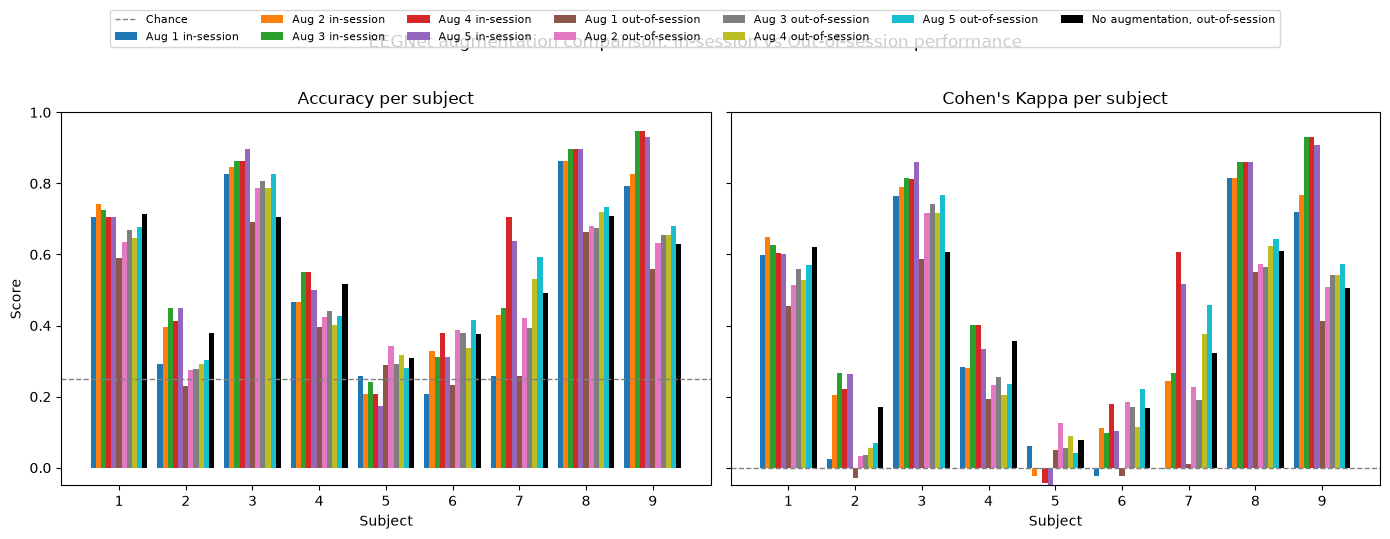

In [33]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Non-augmented baseline
inses_accs = np.loadtxt(Path('results', 'eegnet_inses_accs_regr.csv'), delimiter=',')
outses_accs = np.loadtxt(Path('results', 'eegnet_outses_accs.csv'), delimiter=',')
inses_kappas = np.loadtxt(Path('results', 'eegnet_inses_kappas_regr.csv'), delimiter=',')
outses_kappas = np.loadtxt(Path('results', 'eegnet_outses_kappas.csv'), delimiter=',')

# Augmented results
all_inses_accs_aug = np.loadtxt(Path('results', 'eegnet_all_inses_accs_aug.csv'), delimiter=',')
all_outses_accs_aug = np.loadtxt(Path('results', 'eegnet_all_outses_accs_aug.csv'), delimiter=',')
all_inses_kappas_aug = np.loadtxt(Path('results', 'eegnet_all_inses_kappas_aug.csv'), delimiter=',')
all_outses_kappas_aug = np.loadtxt(Path('results', 'eegnet_all_outses_kappas_aug.csv'), delimiter=',')

n_augs = all_inses_accs_aug.shape[0]
n_subj = all_inses_accs_aug.shape[1]
x = np.arange(n_subj)

# n_augs in-session (augmented) + n_augs out-of-session (augmented) + 1 out-of-session (non-augmented baseline)
n_series = n_augs * 2 + 1
group_width = 0.85
width = group_width / n_series

offsets = (np.arange(n_series) - (n_series - 1) / 2) * width

def plot_grouped(ax, inses_data, outses_data, outses_baseline, title, chance_line, ylim):
    for i in range(n_augs):
        ax.bar(x + offsets[i], inses_data[i], width, label=f"Aug {i+1} in-session")
    for i in range(n_augs):
        ax.bar(x + offsets[n_augs + i], outses_data[i], width, label=f"Aug {i+1} out-of-session")
    # Single non-augmented out-of-session baseline column, appended at the end
    ax.bar(x + offsets[2 * n_augs], outses_baseline, width,
           label="No augmentation, out-of-session", color="black")

    ax.set_title(title)
    ax.set_xlabel("Subject")
    ax.set_xticks(x)
    ax.set_xticklabels(list(range(1, n_subj + 1)))
    ax.axhline(chance_line, color="gray", linestyle="--", linewidth=1, label="Chance")
    ax.set_ylim(*ylim)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

plot_grouped(axes[0], all_inses_accs_aug, all_outses_accs_aug, outses_accs,
             "Accuracy per subject", chance_line=0.25, ylim=(0, 1))
axes[0].set_ylabel("Score")

plot_grouped(axes[1], all_inses_kappas_aug, all_outses_kappas_aug, outses_kappas,
             "Cohen's Kappa per subject", chance_line=0.0, ylim=(-0.05, 1))

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=n_augs + 2, bbox_to_anchor=(0.5, 1.08), fontsize=8)

fig.suptitle("EEGNet augmentation comparison: In-session vs Out-of-session performance", y=1.02)
fig.tight_layout()
# fig.savefig("subject_scores.png", dpi=150)
plt.show()